In [1]:
import pandas as pd
import numpy as np

# NLP + ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Text preprocessing
import re
import string

# Visualization
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("eurostat_nuts3_tables_avail.csv")

df.head()

,table_id,min,max,table_name
0,aei_fm_ms,2000.0,2010.0,Manure storage facilities by NUTS 3 regions
1,aei_pr_soiler,2000.0,2016.0,"Estimated soil erosion by water, by erosion le..."
2,bd_enace2_r3,2008.0,2017.0,Employer business demography by NACE Rev. 2 an...
3,bd_esize_r3,2008.0,2017.0,Employer business demography by size class and...
4,bd_hgnace2_r3,2008.0,2017.0,Business demography and high growth enterprise...


In [3]:
print(df.info())
print(df.columns)
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   table_id    64 non-null     str    
 1   min         59 non-null     float64
 2   max         59 non-null     float64
 3   table_name  64 non-null     str    
dtypes: float64(2), str(2)
memory usage: 7.0 KB
None
Index(['table_id', 'min', 'max', 'table_name'], dtype='str')
table_id      0
min           5
max           5
table_name    0
dtype: int64


In [4]:
# Try common text columns (edit if needed)
possible_text_cols = ['title', 'description', 'label', 'table_name']

text_col = None
for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

print("Using text column:", text_col)

Using text column: table_name


In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df[text_col].apply(clean_text)
df[['clean_text']].head()

,clean_text
0,manure storage facilities by nuts regions
1,estimated soil erosion by water by erosion lev...
2,employer business demography by nace rev and n...
3,employer business demography by size class and...
4,business demography and high growth enterprise...


In [6]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df['clean_text'])
print(X.shape)

(64, 350)


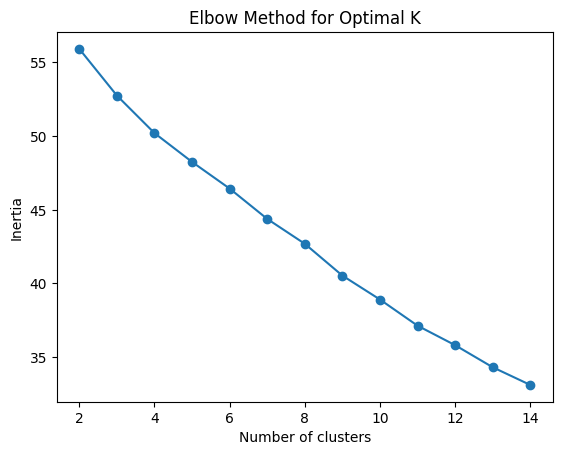

In [7]:
inertia = []

K_range = range(2, 15)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [8]:
k = 5  # change based on elbow result

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

df[['clean_text', 'cluster']].head()

,clean_text,cluster
0,manure storage facilities by nuts regions,2
1,estimated soil erosion by water by erosion lev...,2
2,employer business demography by nace rev and n...,2
3,employer business demography by size class and...,2
4,business demography and high growth enterprise...,2


In [9]:
terms = vectorizer.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    print(f"\nCluster {i}:")
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_terms))


Cluster 0:
region, nuts region, area, area nuts, nuts, total nuts, indicators nuts, total, indicators, deaths

Cluster 1:
applications, nuts regions, patent, regions, design cd, design, community design, cd applications, cd, community

Cluster 2:
nuts regions, regions, nuts, population, status, population sex, status nuts, sex, sex age, persons

Cluster 3:
road freight, goods, road, nuts group, group goods, freight, freight transport, national, national annual, transport

Cluster 4:
nuts region, region, age, sex, age group, deaths, group, sex nuts, week sex, week


In [10]:
pca = PCA(n_components=2)
X_dense = X.toarray()
coords = pca.fit_transform(X_dense)

df['x'] = coords[:, 0]
df['y'] = coords[:, 1]

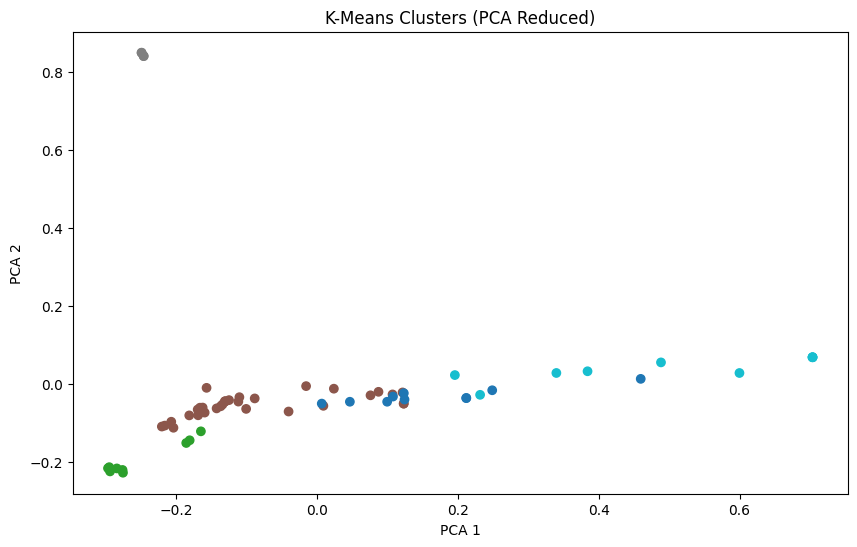

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(df['x'], df['y'], c=df['cluster'], cmap='tab10')
plt.title("K-Means Clusters (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [12]:
for i in range(k):
    print(f"\n===== Cluster {i} Samples =====")
    print(df[df['cluster'] == i][text_col].head(5).values)


===== Cluster 0 Samples =====
<ArrowStringArray>
['Conventional dwellings by occupancy status, type of building and NUTS 3 region',
                                       'Families by type, size and NUTS 3 region',
                                           'Live births (total) by NUTS 3 region',
                                                          'Area by NUTS 3 region',
                                            'Population density by NUTS 3 region']
Length: 5, dtype: str

===== Cluster 1 Samples =====
<ArrowStringArray>
[                  'Community design (CD) applications per billion GDP by NUTS 3 regions',
            'Community design (CD) applications per million population by NUTS 3 regions',
                                   'Community design (CD) applications by NUTS 3 regions',
        'European Union trade mark (EUTM) applications per billion GDP by NUTS 3 regions',
 'European Union trade mark (EUTM) applications per million population by NUTS 3 regions']
Length: 